# Rule Text Analysis

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
results_dir = Path('.')

def clean_rule_text(text):
    text = re.sub(r'R\d+:\s*', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def count_words(text):
    return len(re.findall(r'\b\w+\b', text))

def count_subrules(text):
    # Count patterns like "R1:", "R2:", etc.
    return len(re.findall(r'R\d+:', text))

def extract_prompt_version(path):
    match = re.search(r'_(promptV\d+)_\d+_\d+_llm_results\.jsonl$', path.name)
    return match.group(1) if match else 'promptV0'

def load_rule_rows():
    rows = []
    for path in sorted(results_dir.glob('*_rulebased_*_llm_results.jsonl')):
        prompt_version = extract_prompt_version(path)
        with open(path, 'r') as f:
            for line in f:
                run = json.loads(line)
                for class_name, rule_text in run.get('extracted_rules', {}).items():
                    # Count subrules BEFORE cleaning
                    num_subrules = count_subrules(rule_text)
                    rule_text = clean_rule_text(rule_text)
                    if not rule_text:
                        continue

                    rows.append({
                        'dataset': run['dataset'],
                        'k': run['k'],
                        'num_rules_setting': run['num_rules'],
                        'prompt_version': prompt_version,
                        'accuracy': run['accuracy'],
                        'repetition': run.get('repetition'),
                        'class_name': class_name,
                        'rule_text': rule_text,
                        'num_words': count_words(rule_text),
                        'num_chars': len(rule_text),
                        'num_subrules': num_subrules,  # Use pre-cleaned count
                    })
    return pd.DataFrame(rows)

def load_run_rows():
    rows = []
    for path in sorted(results_dir.glob('*_rulebased_*_llm_results.jsonl')):
        prompt_version = extract_prompt_version(path)
        with open(path, 'r') as f:
            for line in f:
                run = json.loads(line)
                rule_texts = [clean_rule_text(text) for text in run.get('extracted_rules', {}).values()]
                rule_texts = [text for text in rule_texts if text]
                if not rule_texts:
                    continue

                rows.append({
                    'dataset': run['dataset'],
                    'k': run['k'],
                    'num_rules_setting': run['num_rules'],
                    'prompt_version': prompt_version,
                    'accuracy': run['accuracy'],
                    'repetition': run.get('repetition'),
                    'num_class_rules': len(rule_texts),
                    'total_num_words': sum(count_words(text) for text in rule_texts),
                    'total_num_chars': sum(len(text) for text in rule_texts),
                })
    return pd.DataFrame(rows)

def plot_scatter(df, metric, title, xlabel):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(df[metric], df['accuracy'], alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy')
    ax.grid(alpha=0.2)
    plt.show()

def plot_scatter_per_dataset(df, metric, xlabel):
    datasets = sorted(df['dataset'].unique())
    fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4), squeeze=False)
    for ax, dataset in zip(axes[0], datasets):
        subset = df[df['dataset'] == dataset]
        ax.scatter(subset[metric], subset['accuracy'], alpha=0.7)
        ax.set_title(dataset)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Accuracy')
        ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

def fit_line(df, metric):
    if len(df) < 2 or df[metric].nunique() < 2:
        return np.nan, np.nan, np.nan
    x = df[metric].to_numpy()
    y = df['accuracy'].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    corr = np.corrcoef(x, y)[0, 1]
    return slope, intercept, corr

def plot_trend(df, metric, title, xlabel):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(df[metric], df['accuracy'], alpha=0.7)
    slope, intercept, corr = fit_line(df, metric)
    if pd.notna(slope):
        x = np.linspace(df[metric].min(), df[metric].max(), 100)
        ax.plot(x, slope * x + intercept, color='black')
        ax.set_title(f'{title} (corr={corr:.3f})')
    else:
        ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy')
    ax.grid(alpha=0.2)
    plt.show()

def plot_trend_per_dataset(df, metric, xlabel):
    datasets = sorted(df['dataset'].unique())
    fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4), squeeze=False)
    for ax, dataset in zip(axes[0], datasets):
        subset = df[df['dataset'] == dataset]
        ax.scatter(subset[metric], subset['accuracy'], alpha=0.7)
        slope, intercept, corr = fit_line(subset, metric)
        if pd.notna(slope):
            x = np.linspace(subset[metric].min(), subset[metric].max(), 100)
            ax.plot(x, slope * x + intercept, color='black')
            ax.set_title(f'{dataset} (corr={corr:.3f})')
        else:
            ax.set_title(dataset)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Accuracy')
        ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

def plot_trend_per_dataset_with_legend(df, metric, xlabel, color_metric, color_map=None):
    datasets = sorted(df['dataset'].unique())
    fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4), squeeze=False)

    for ax, dataset in zip(axes[0], datasets):
        subset = df[df['dataset'] == dataset].copy()
        subset[color_metric] = subset[color_metric].astype(int)

        unique_values = sorted(subset[color_metric].dropna().unique())

        for value in unique_values:
            group = subset[subset[color_metric] == value]
            color = color_map.get(value) if color_map is not None else None

            ax.scatter(
                group[metric],
                group['accuracy'],
                color=color,
                alpha=0.7,
                s=50,
                label=f'{color_metric}={value}'
            )

        slope, intercept, corr = fit_line(subset, metric)
        if pd.notna(slope):
            x = np.linspace(subset[metric].min(), subset[metric].max(), 100)
            ax.plot(x, slope * x + intercept, color='black')
            ax.set_title(f'{dataset} (corr={corr:.3f})')
        else:
            ax.set_title(dataset)

        ax.set_xlabel(xlabel)
        ax.set_ylabel('Accuracy')
        ax.grid(alpha=0.2)
        ax.legend(title=color_metric)

    fig.tight_layout()
    plt.show()

def correlation_table(df, metric):
    rows = []
    for dataset, subset in df.groupby('dataset'):
        slope, intercept, corr = fit_line(subset, metric)
        rows.append({'dataset': dataset, 'slope': slope, 'corr': corr, 'count': len(subset)})
    return pd.DataFrame(rows).round(3)


In [3]:
rules_df = load_rule_rows()
runs_df = load_run_rows()
print(rules_df.shape)
display(rules_df.head())
print(runs_df.shape)
display(runs_df.head())


(167, 11)


,dataset,k,num_rules_setting,prompt_version,accuracy,repetition,class_name,rule_text,num_words,num_chars,num_subrules
0,Chinatown,2,2,promptV0,0.85,1,class_0,The series starts at a clearly positive level ...,53,299,2
1,Chinatown,2,2,promptV0,0.85,1,class_1,The series starts very close to zero and remai...,56,297,2
2,Chinatown,2,2,promptV0,0.90,2,class_0,In the very early part of the series (time ste...,55,285,2
3,Chinatown,2,2,promptV0,0.90,2,class_1,In the very early part of the series (time ste...,61,331,2
4,Chinatown,2,2,promptV0,0.94,3,class_0,The value at time 0 is at least 0.15 higher th...,60,286,2


(76, 9)


,dataset,k,num_rules_setting,prompt_version,accuracy,repetition,num_class_rules,total_num_words,total_num_chars
0,Chinatown,2,2,promptV0,0.85,1,2,109,596
1,Chinatown,2,2,promptV0,0.90,2,2,116,616
2,Chinatown,2,2,promptV0,0.94,3,2,111,544
3,Chinatown,3,1,promptV0,0.93,1,2,45,205
4,Chinatown,3,1,promptV0,0.92,2,2,57,229


In [4]:
rules_df = rules_df[rules_df['k'] == 3]
runs_df = runs_df[runs_df['k'] == 3]


In [5]:
runs_df.groupby(['dataset', 'num_rules_setting'])['accuracy'].agg(['count', 'mean']).round(3)


count   mean
dataset               num_rules_setting              
Chinatown             0                      6  0.967
                      1                      2  0.925
                      2                      2  0.820
                      3                      2  0.955
ECG200                0                      6  0.687
                      1                      3  0.457
                      2                      3  0.640
                      3                      3  0.680
ItalyPowerDemand      0                      6  0.822
                      2                      3  0.747
SonyAIBORobotSurface1 0                      6  0.610
                      1                      3  0.550
                      2                      3  0.573
                      3                      3  0.573
UMD                   0                      6  0.893
                      1                      3  0.953
                      2                      3  0.910
                      3                      3  0.923

## Word Analysis

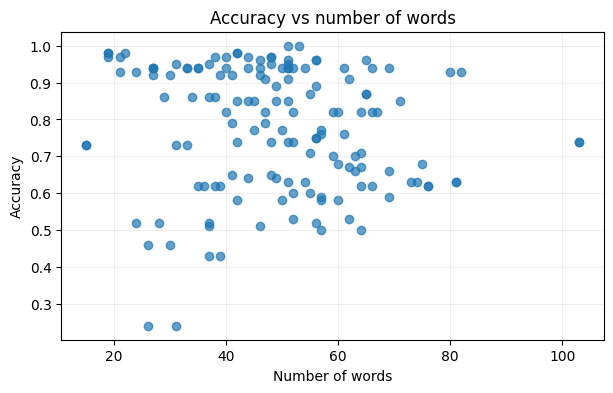

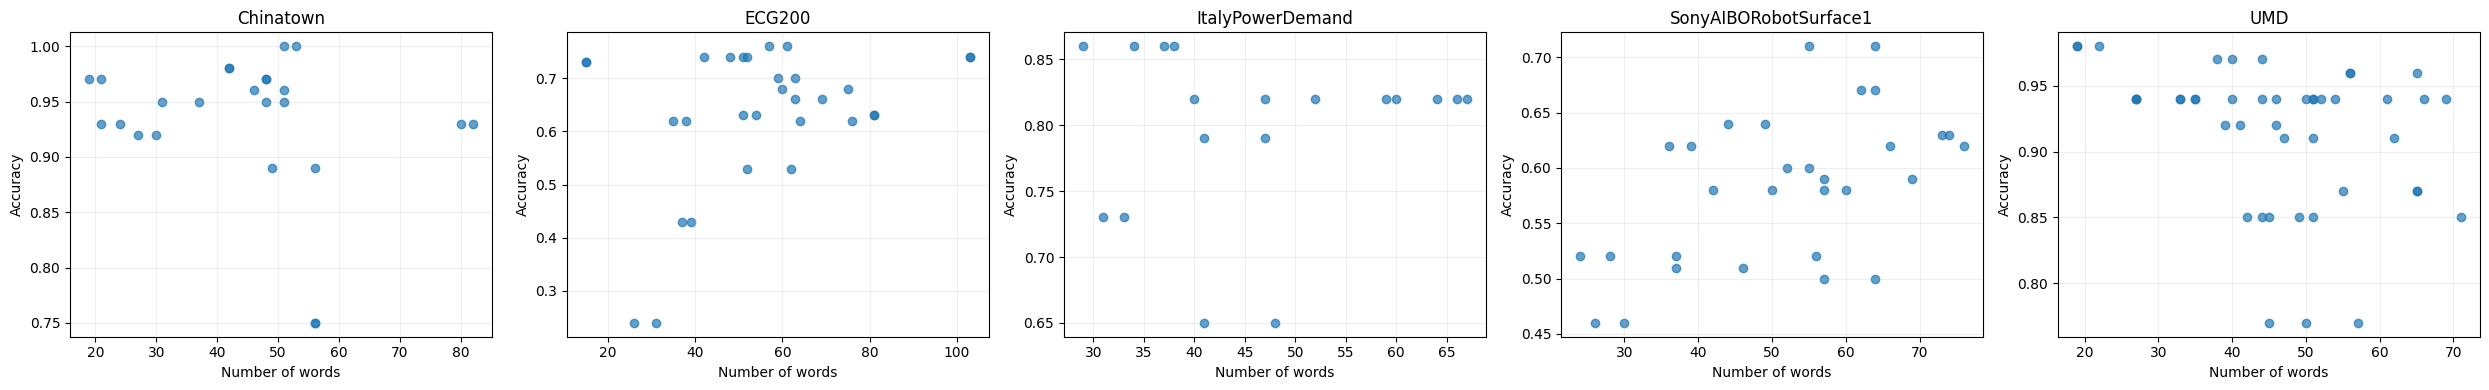

In [6]:
plot_scatter(rules_df, 'num_words', 'Accuracy vs number of words', 'Number of words')
plot_scatter_per_dataset(rules_df, 'num_words', 'Number of words')


Pearson Correlation Coefficient

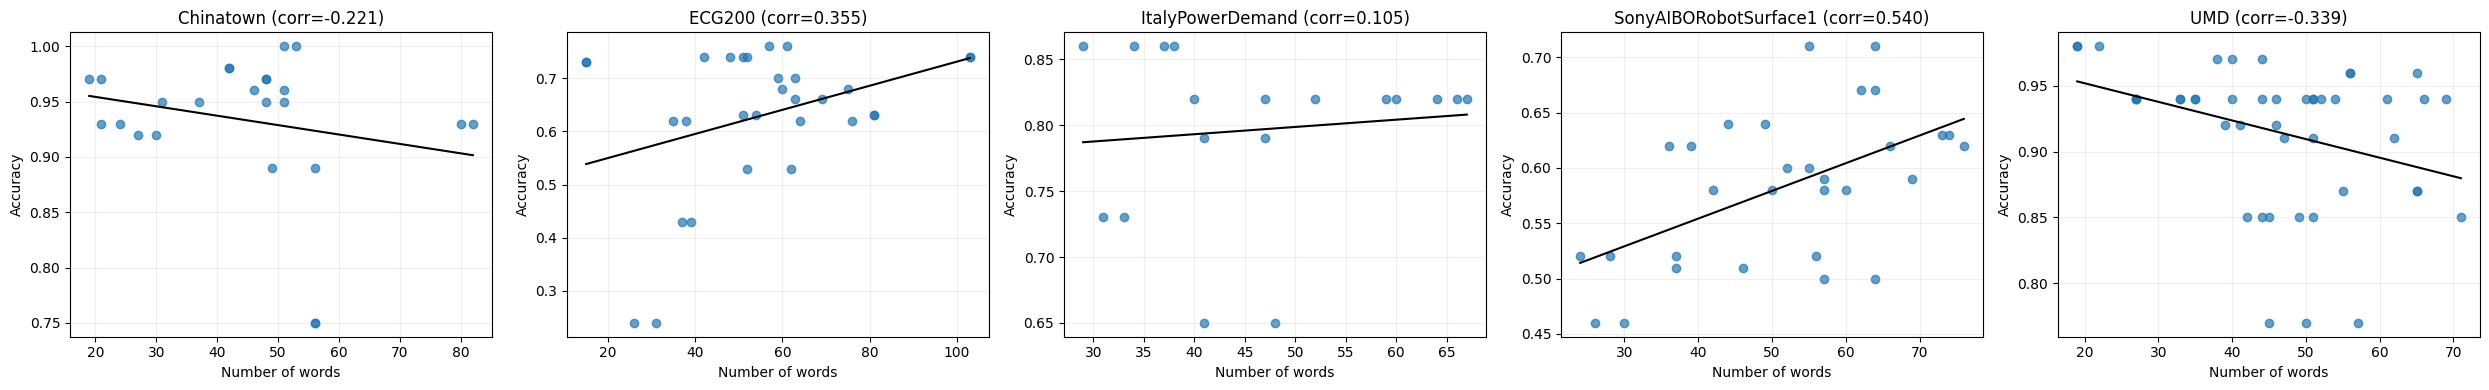

,dataset,slope,corr,count
0,Chinatown,-0.001,-0.221,24
1,ECG200,0.002,0.355,30
2,ItalyPowerDemand,0.001,0.105,18
3,SonyAIBORobotSurface1,0.003,0.540,30
4,UMD,-0.001,-0.339,45


In [7]:
plot_trend_per_dataset(rules_df, 'num_words', 'Number of words')
display(correlation_table(rules_df, 'num_words'))


## Aggregated Word Analysis


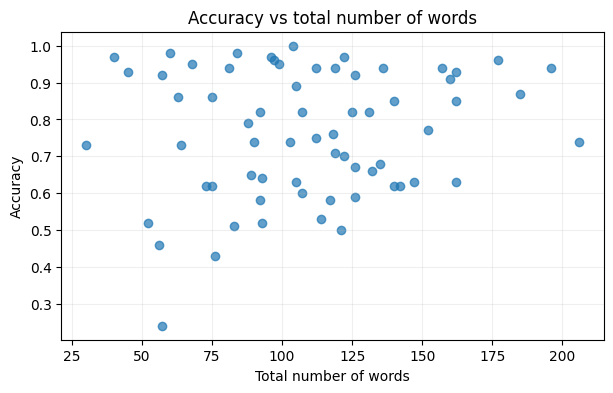

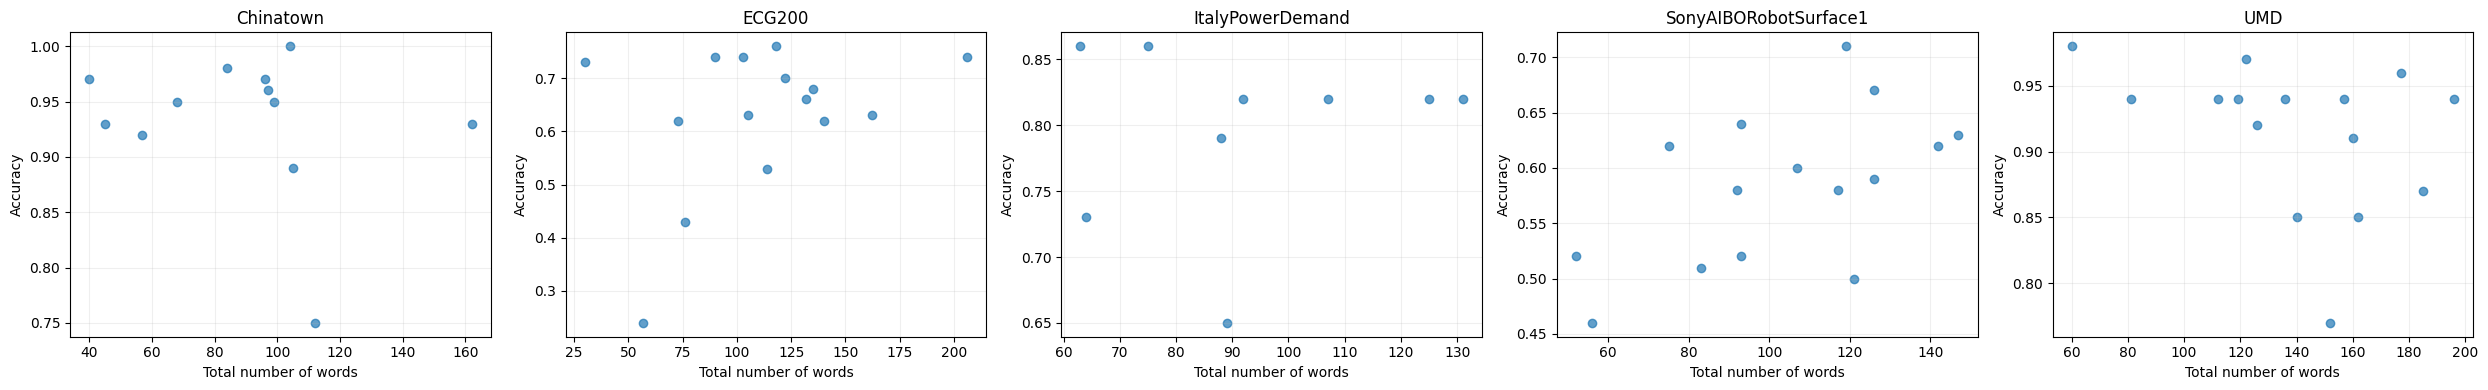

In [8]:
plot_scatter(runs_df, 'total_num_words', 'Accuracy vs total number of words', 'Total number of words')
plot_scatter_per_dataset(runs_df, 'total_num_words', 'Total number of words')


Pearson correlation coefficient


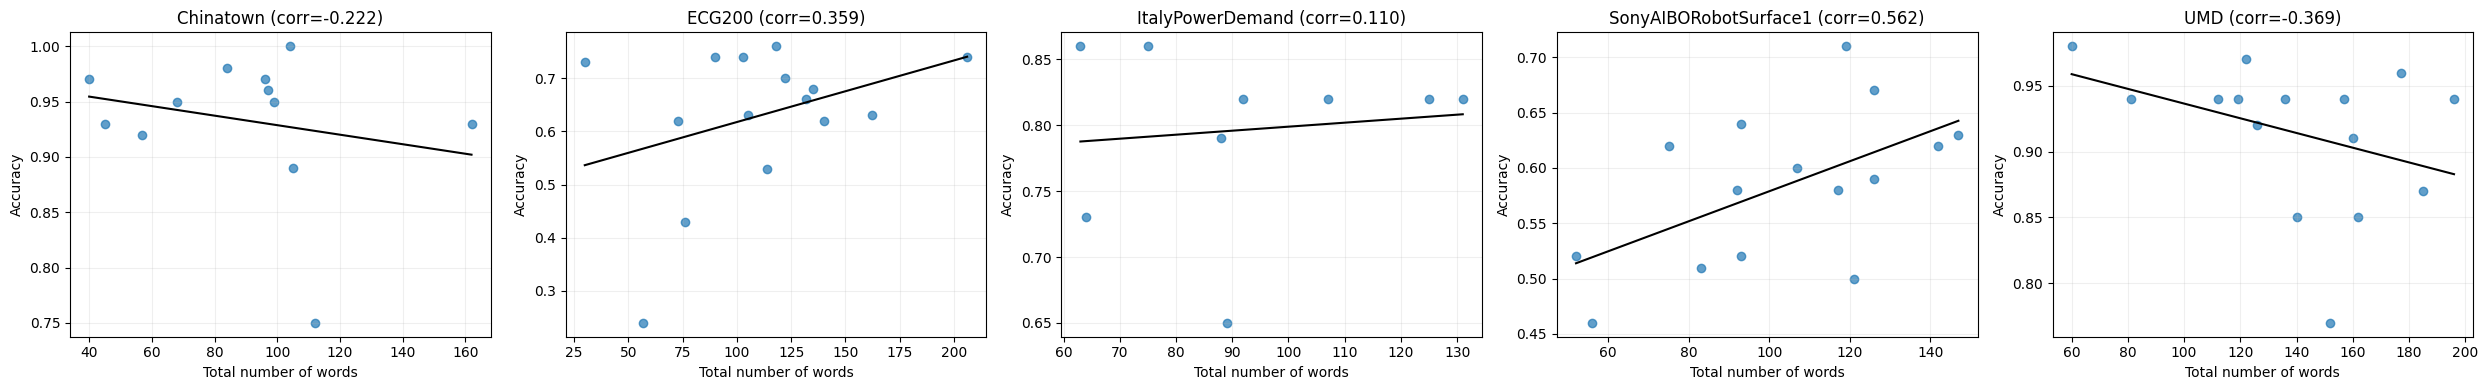

,dataset,slope,corr,count
0,Chinatown,-0.000,-0.222,12
1,ECG200,0.001,0.359,15
2,ItalyPowerDemand,0.000,0.110,9
3,SonyAIBORobotSurface1,0.001,0.562,15
4,UMD,-0.001,-0.369,15


In [9]:
plot_trend_per_dataset(runs_df, 'total_num_words', 'Total number of words')
display(correlation_table(runs_df, 'total_num_words'))


## Character Analysis

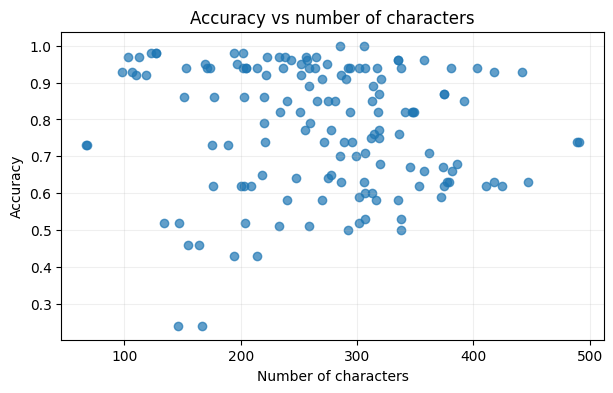

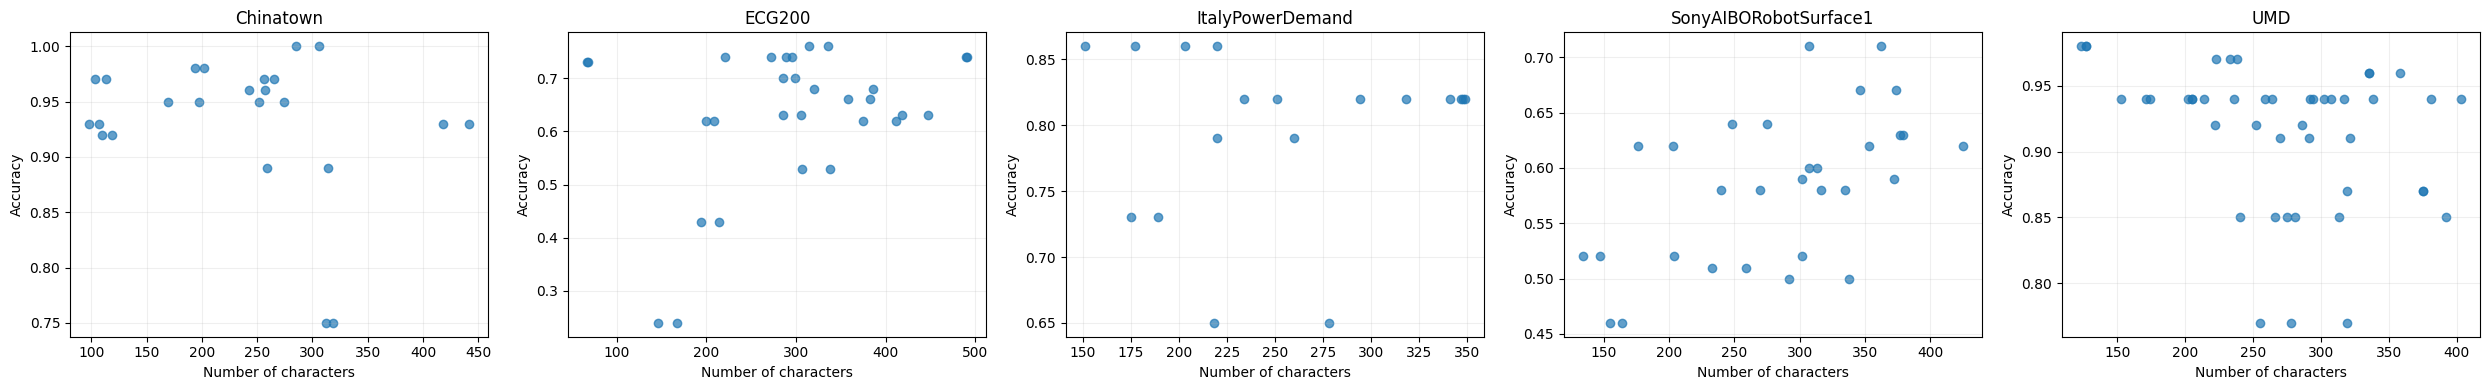

In [10]:
plot_scatter(rules_df, 'num_chars', 'Accuracy vs number of characters', 'Number of characters')
plot_scatter_per_dataset(rules_df, 'num_chars', 'Number of characters')


Pearson correlation coefficient

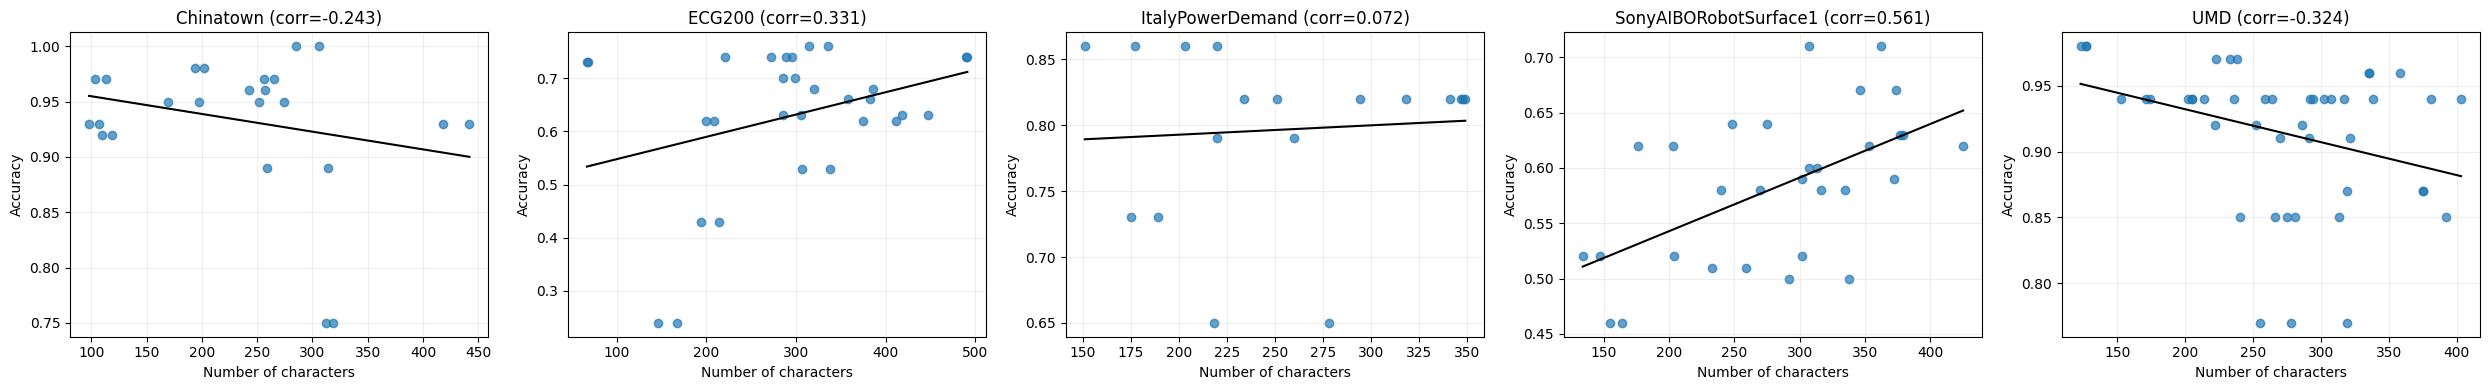

,dataset,slope,corr,count
0,Chinatown,-0.0,-0.243,24
1,ECG200,0.0,0.331,30
2,ItalyPowerDemand,0.0,0.072,18
3,SonyAIBORobotSurface1,0.0,0.561,30
4,UMD,-0.0,-0.324,45


In [11]:
plot_trend_per_dataset(rules_df, 'num_chars', 'Number of characters')
display(correlation_table(rules_df, 'num_chars'))


## New prompts

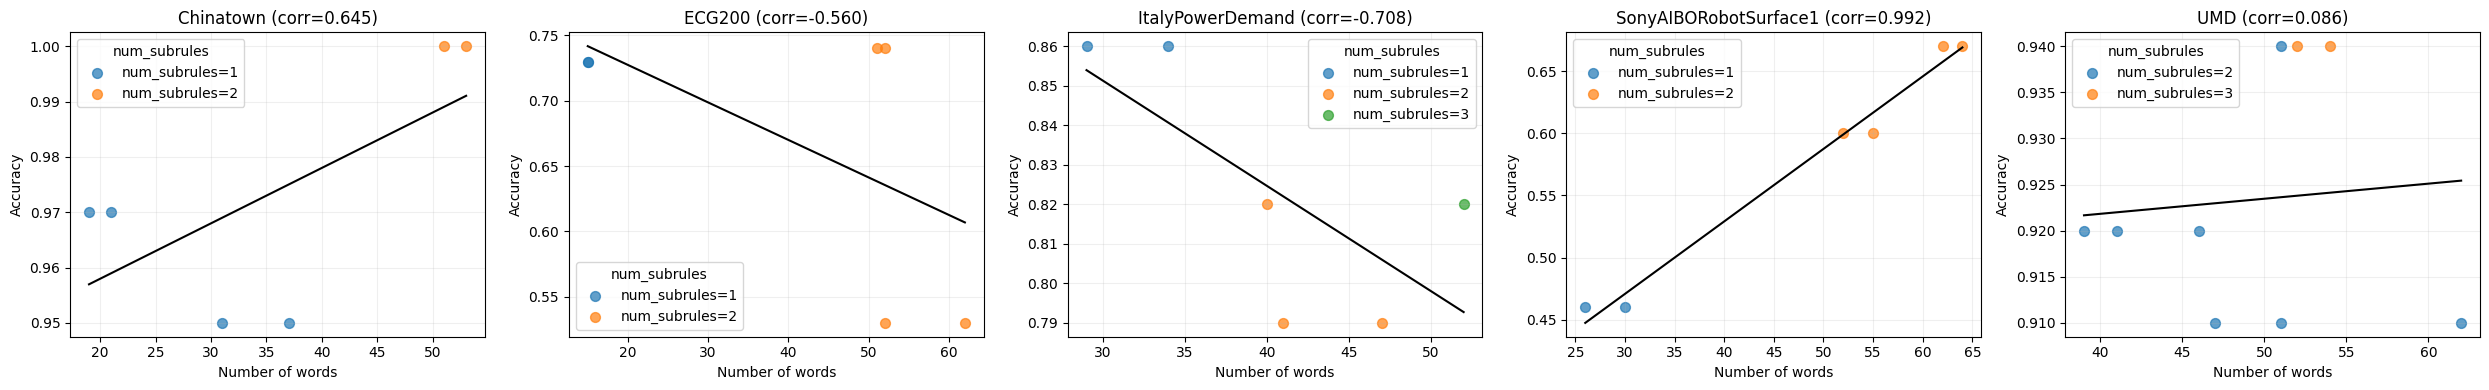

In [12]:
subset_promptV3 = rules_df[rules_df['prompt_version'] == 'promptV3']
plot_trend_per_dataset_with_legend(subset_promptV3, 'num_words', 'Number of words', color_metric='num_subrules')

### get each plot individually and the colors consistent

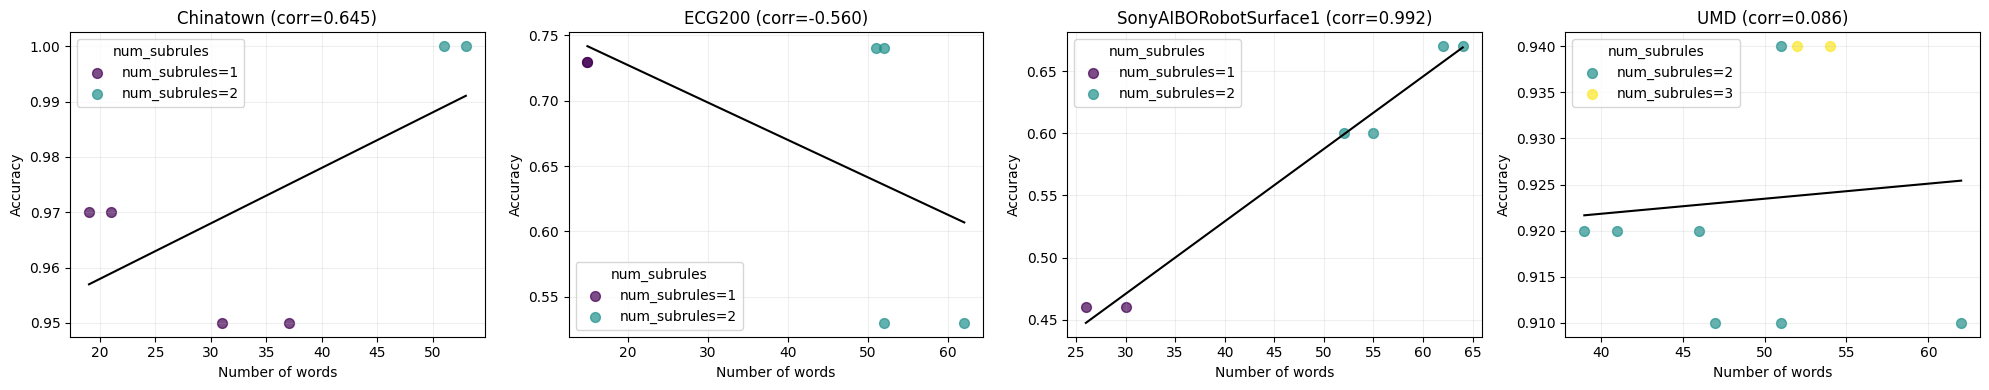

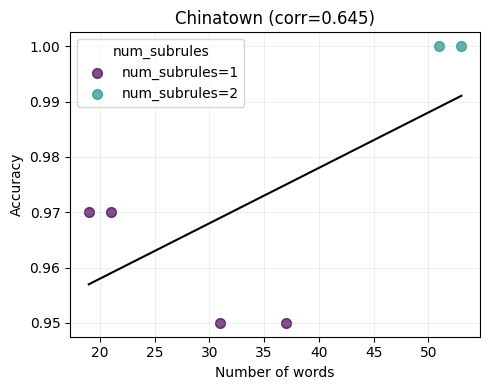

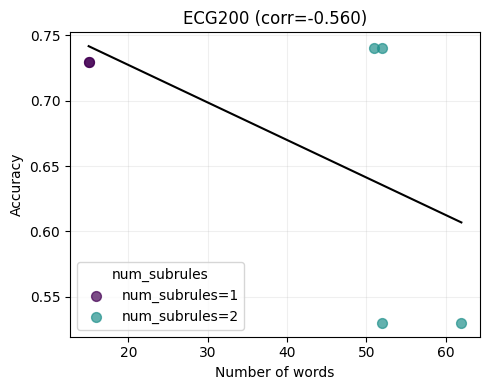

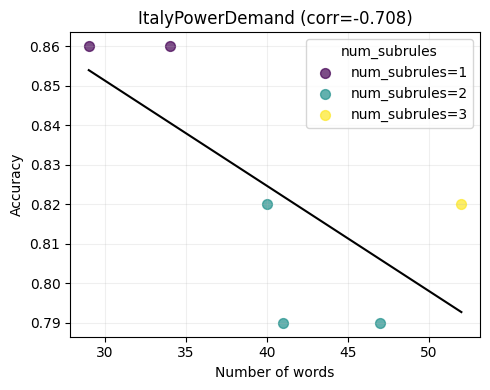

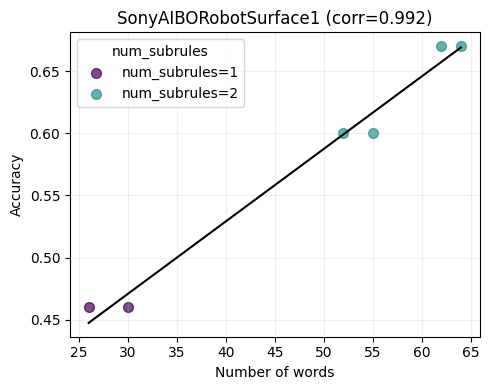

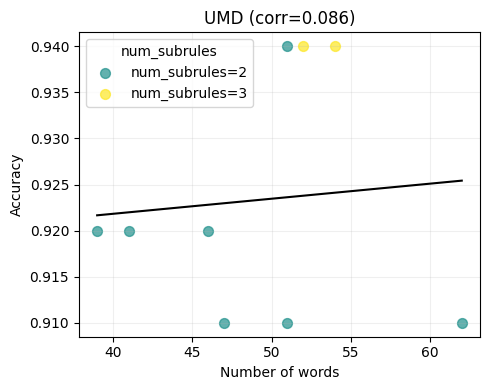

In [16]:
all_values = sorted(rules_df['num_subrules'].dropna().astype(int).unique())
cmap = plt.get_cmap('viridis', len(all_values))
color_map = {value: cmap(i) for i, value in enumerate(all_values)}

subset_promptV3_exclude_italy = subset_promptV3[subset_promptV3["dataset"] != "ItalyPowerDemand"]

plot_trend_per_dataset_with_legend(subset_promptV3_exclude_italy,
        'num_words',
        'Number of words',
        color_metric='num_subrules',
        color_map=color_map
    )

for dataset, group in subset_promptV3.groupby('dataset'):
    plot_trend_per_dataset_with_legend(
        group,
        'num_words',
        'Number of words',
        color_metric='num_subrules',
        color_map=color_map
    )

### acc and std.

In [14]:
pv3 = runs_df[runs_df['prompt_version'] == 'promptV3']
if pv3.empty:
    print("No promptV3 rows found")
else:
    table = pv3.groupby(['dataset', 'num_rules_setting'])['accuracy'] \
               .agg(['mean', 'std', 'count']) \
               .round(3) \
               .reset_index()
    table['mean_std'] = table.apply(
        lambda r: f"{r['mean']:.3f} ± {r['std']:.2f}" if not pd.isna(r['std']) else f"{r['mean']:.3f} ± NaN",
        axis=1
    )
    display(table[['dataset', 'mean_std']])

,dataset,mean_std
0,Chinatown,0.973 ± 0.03
1,ECG200,0.667 ± 0.12
2,ItalyPowerDemand,0.823 ± 0.04
3,SonyAIBORobotSurface1,0.577 ± 0.11
4,UMD,0.923 ± 0.01
